In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import textwrap

# библиотеки для NLP
import re
import unicodedata
import nltk
from collections import Counter
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk import SnowballStemmer
from wordcloud import WordCloud
from pymystem3 import Mystem

# библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# для параллельной обработки текста
from multiprocessing import Pool
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# загрузка датасета
df = pd.read_csv('.\\datasets\\spam_ham_dataset.csv', index_col = 0)
df = df.dropna()
df.sample(10, random_state = 5)

,text,label
22760,Умер от кринжовости говнокода?,0
45063,"Я понимаю, по типу киба у сбера что ли?",0
21230,"Any suggestions Dmitry about groups? Because,...",0
21864,Cрочно нyжны люди на пoдpaботку оплaта в дeнь ...,1
2457,Ищем людей для удаленного дохода! Всему обучае...,1
20752,Так такие вещи через флоу делать красиво можно...,0
34581,Можно подсмотреть в исходниках лончера,0
10976,Нашему тезке 500,0
27065,Ищу встречи сейчас только русские,1
19211,Плaтим 6к зa не трудную зaдачу нyжен тeлефон c...,1


In [4]:
print(f'Размерность датасета: {df.shape}, количество пропусков: {df.isna().sum().sum()}')
print(f'Количество спам-сообщений: {df.label.sum()} ({df.label.sum() / len(df) * 100:.2f} %)')

Размерность датасета: (55733, 2), количество пропусков: 0
Количество спам-сообщений: 19026 (34.14 %)


### Предобработка текста


In [ ]:
# --------------------------------------------
# СТАНДАТНАЯ ПРЕДОБРАБОТКА ТЕКСТА
# --------------------------------------------
def clean_text(text):
    text = text.replace('\n', ' ').replace('\r', ' ')          # убираю переносы строк
    
    # убираю скрытые символы юникода
    text = unicodedata.normalize('NFKC', text)
    text = ''.join(
        char for char in text 
        if unicodedata.category(char) not in ['Cc', 'Cf', 'Co', 'Cn']
    )
    text = text.strip().lower() 
    text = re.sub(r'(?<=\d)\s+(?=\d)', '', text)
    text = re.sub(
        r'(https?://\S+|www\.\S+|t\.me/[a-zA-Z0-9_]+|[a-zA-Z0-9-]+\.(?:com|ru|org|net|me|io)/[a-zA-Z0-9_/]+)', 
        ' LINK ', 
        text
    )
    text = re.sub(r'@\w+', ' USERNAME ', text)                 # замена @username на токен USERNAME
    text = re.sub(r'#\w+', ' HASHTAG ', text)                  # замена #hashtag на токен HASHTAG
    
    # функция, которая заменяет похожие на русские буквы символы
    def translit(word):
        homoglyphs = {
            '@': 'а', 'ō': 'о', 'ė': 'е', 'η' : 'н',
            'ă': 'а', 'Û': 'И', 'u': 'и', 'α' : 'а',
            'a': 'а', 'A': 'А', 'o': 'о', 'O': 'О',
            'e': 'е', 'E': 'Е', 'p': 'р', 'P': 'Р',
            'c': 'с', 'C': 'С', 'x': 'х', 'X': 'Х',
            'y': 'у', 'Y': 'У', 'B': 'В', 'K': 'К',
            'M': 'М', 'H': 'Н', 'T': 'Т', 'B' : 'В', 
            'σ':'о', 'π' : 'п', 'γ': 'у', 'ο' : 'о', 
            'ρ' : 'р', 't' : 'т', 'ᴍ' : 'м', 'h' : 'н',
            'ᴄ' : 'с', 'ᴋ' : 'к', 'τ' : 'т', 
            'ε' : 'е', 'β' : 'в', 'κ' : 'к', 'μ' : 'м',
        } #'0': 'о', '6': 'б','4': 'ч', 3': 'з','8': 'в', 

        # cyrilic = re.findall(r'[А-Яа-яЁё]', word)
        # other = re.findall(r'[A-Za-zα-ωĀ-žÀ-ÿ0-9]', word)

        # Проверяем, есть ли в слове кириллица
        has_cyrillic = bool(re.search(r'[А-Яа-яЁё]', word))
        # Проверяем, есть ли цифры-омоглифы
        has_homoglyph_digits = bool(re.search(r'[046]', word))
        # Проверяем, есть ли другие подозрительные символы (латиница, греческий)
        has_suspicious = bool(re.search(r'[A-Za-zα-ω]', word))

        # if len(cyrilic) > 0 and len(other) > 0:
        if has_cyrillic and (has_homoglyph_digits or has_suspicious):
            for eng, rus in homoglyphs.items():
                word = word.replace(eng, rus)

            word = re.sub(
                r'(?<=[а-яА-ЯёЁ])0(?![0-9])|(?<![0-9])0(?=[а-яА-ЯёЁ])',
                'о', word
            )

            # 6 → б 
            word = re.sub(
                r'(?<=[а-яА-ЯёЁa-zA-Zα-ω])6(?![0-9])|(?<![0-9])6(?=[а-яА-ЯёЁa-zA-Zα-ω])',
                'б', word
            )
            
            # 4 → ч 
            word = re.sub(
                r'(?<=[а-яА-ЯёЁa-zA-Zα-ω])4(?![0-9])|(?<![0-9])4(?=[а-яА-ЯёЁa-zA-Zα-ω])',
                'ч', word
            )

            # 4 → ч (аналогичная логика)
            word = re.sub(
                r'(?<=[а-яА-ЯёЁa-zA-Zα-ω])3(?![0-9])|(?<![0-9])3(?=[а-яА-ЯёЁa-zA-Zα-ω])',
                'з', word
            )
            word = re.sub(
                r'(?<=[а-яА-ЯёЁa-zA-Zα-ω])8(?![0-9])|(?<![0-9])8(?=[а-яА-ЯёЁa-zA-Zα-ω])',
                'в', word
            )

            word = re.sub(
                r'(?<=[а-яА-ЯёЁa-zA-Zα-ω])60(?![0-9])|(?<![0-9])60(?=[а-яА-ЯёЁa-zA-Zα-ω])',
                'в', word
            )

        return word
    
    text = ' '.join([translit(word) for word in text.split()])    
    
    text = re.sub(r'[^A-Za-zА-Яа-яЁё0-9 ]+', ' ', text)          # оставляю чисто буквы и цифры
    text = re.sub(r'\d+', ' NUM ', text)                         # замена чисел на на токен NUM
    text = re.sub(r'\s+', ' ', text).strip()                     # убираю лишние пробелы
    text = re.sub(r'(NUM\s+)+NUM', 'NUM', text)                  # убираю повторяющиеся подряд токены NUM
    return text

df['text_clean'] = Parallel(n_jobs = 8)(
    delayed(clean_text)(text) 
    for text in tqdm(df['text'], desc = 'ЭТАП 1: очистка текста')
)
df = df[df['text'] != '']

ЭТАП 1: очистка текста: 100%|██████████| 55733/55733 [00:00<00:00, 88877.87it/s] 


In [7]:
# СТОП-СЛОВА
stop = stopwords.words('russian')
stop.extend(['это', 'наш', 'ваш', 'который', 'свой'])
russian_stopwords = frozenset(stop)

# --------------------------------------------
# ЛЕММАТИЗАЦИЯ И УДАЛЕНИЕ СТОП-СЛОВ
# --------------------------------------------
m = Mystem()
def lemma_text_preprocess(text):
    lemmas = ' '.join(m.lemmatize(text))
    words = [word for word in lemmas.split() if word not in russian_stopwords and len(word) > 1]
    return ' '.join(words)

df['text_lemmatized'] = Parallel(n_jobs = -1)(
    delayed(lemma_text_preprocess)(text) 
    for text in tqdm(df['text_clean'], desc = 'ЭТАП 2: лемматизация текста'))

# --------------------------------------------
#  СТЕММИНГ И УДАЛЕНИЕ СТОП-СЛОВ
# --------------------------------------------
stemmer = SnowballStemmer("russian")
russian_stopwords = frozenset(stopwords.words('russian'))

def stemmer_text_preprocess(text):
    text = text.split()
    words = [stemmer.stem(word) for word in text if word not in russian_stopwords and len(word) > 1]
    return ' '.join(words)

df['text_stemmer'] = Parallel(n_jobs = 1)(
    delayed(stemmer_text_preprocess)(text) 
    for text in tqdm(df['text_clean'], desc = 'ЭТАП 3: стемминг текста')
)

ЭТАП 3: стемминг текста: 100%|██████████| 55733/55733 [00:09<00:00, 5621.77it/s]


In [ ]:
# удаляю дубликаты
df.drop_duplicates(keep = 'first', inplace = True, ignore_index = True)
df.to_csv('.\\datasets\\ham_spam_dataset_preprocessed.csv')

# EDA

In [12]:
df = pd.read_csv('.\\datasets\\ham_spam_dataset_preprocessed.csv', index_col = 0)
df.dropna(inplace = True, ignore_index = True)
df.head(5)

,text,label,text_clean,text_lemmatized,text_stemmer
0,ироды нечестивые,0,ироды нечестивые,ирод нечестивый,ирод нечестив
1,"да и что там настраивать? главное, программу з...",0,да и что там настраивать главное программу зап...,настраивать главное программа запуск игра выби...,настраива главн программ запуск игр выбра наст...
2,Или я чего то не понимать,0,или я чего то не понимать,понимать,понима
3,"Всем привет, во всех гайдах по спрингу в аннот...",0,всем привет во всех гайдах по спрингу в аннота...,привет весь гайд спринг аннотация маппинг пере...,всем привет гайд спринг аннотац маппинг переда...
4,На спине или ногах,0,на спине или ногах,спина нога,спин ног


In [13]:
def df_check (df):
    # размер датасета
    a = df.shape
    
    # размер спама
    spam = df.label.sum()

    # узнаём количество пропусков
    n = df.isna().sum() 

    # посмотрим, есть ли пустые строки
    # словарь, чтобы записывать пустые строки
    box = {}

    # проход только по строковым столбцам
    for i in df.select_dtypes(include=['object', 'string']).columns: 
        box[i] = (df[i] == '').sum()
    
    # дубликаты в text
    c = df.duplicated(subset=['text']).sum()

    # дубликаты после лемматизации
    l = df.duplicated(subset=['text_lemmatized']).sum()

    print(f'Размер датасета: {a}')
    print(f'Количество спам-сообщений: {spam} ({df.label.sum() / len(df) * 100:.2f} %)\n')
    print(f'Количество пропусков: \n{n[n > 0] if n.any() else 'пропусков нет'}')
    print(f'\nПустые строки: {box if any(box.values()) else 'пустых строк нет'}')
    print(f'Дубликаты в очищенном тексте: {c if c > 0 else 'дубликатов нет'}')
    print(f'Дубликаты после лемматизации: {l if l > 0 else 'дубликатов нет'}')

df_check (df)

Размер датасета: (55338, 5)
Количество спам-сообщений: 18996 (34.33 %)

Количество пропусков: 
пропусков нет

Пустые строки: пустых строк нет
Дубликаты в очищенном тексте: дубликатов нет
Дубликаты после лемматизации: 6938


In [14]:
# посчитаем дубликаты отдельно для каждого класса после лемматизации
print(df[df['label'] == 0].duplicated(subset=['text_lemmatized']).sum(), "- в классе Ham")
print(df[df['label'] == 1].duplicated(subset=['text_lemmatized']).sum(), "- в классе Spam")

1333 - в классе Ham
5600 - в классе Spam


### Визуализация

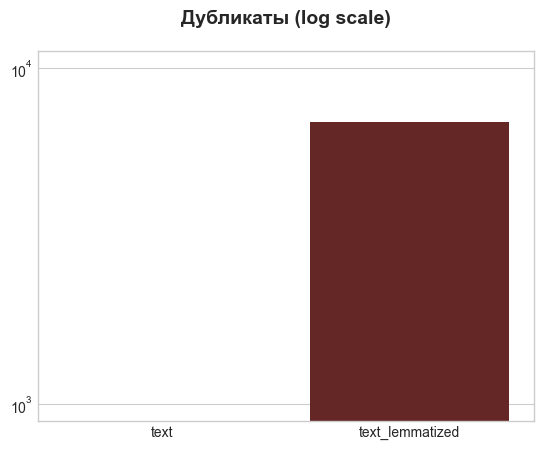

In [15]:
# график для дубликатов text и text_lemmatized
x = ['text', 'text_lemmatized']
y = [df['text'].duplicated().sum(), df['text_lemmatized'].duplicated().sum()]

sns.barplot(
    x=x, 
    y=y, 
    hue=x, 
    palette=["#31572c", '#6f1d1b']
)

plt.yscale('log') # делаем столбик 'text' заметее на фоне 'text_lemmatized'
plt.title('Дубликаты (log scale)', fontsize=14, fontweight='bold', pad=20)
plt.show()

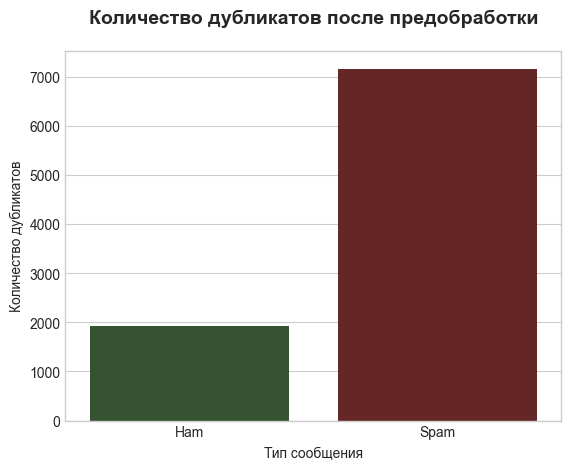

In [16]:
# график количества дубликатов в леммат. варианте
sns.countplot(
    data=df[df.duplicated(subset=['text_lemmatized'], keep=False)],
    x='label',
    hue=df['label'].map({0: 'Ham', 1: 'Spam'}),
    palette=["#31572c", '#6f1d1b'],
    legend=False,
)

plt.title('Количество дубликатов после предобработки', fontsize=14, fontweight='bold', pad=20)
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.xlabel('Тип сообщения')
plt.ylabel('Количество дубликатов')
plt.show()

основная масса скрытых дубликатов (после лемматизации) сосредоточена в классе Spam. Это связано с обилием шаблонных фраз, общих паттернов, которые в очищенном виде сводятся к одним и тем же леммам. В то же время ham-сообщения демонстрируют большую лексическую вариативность

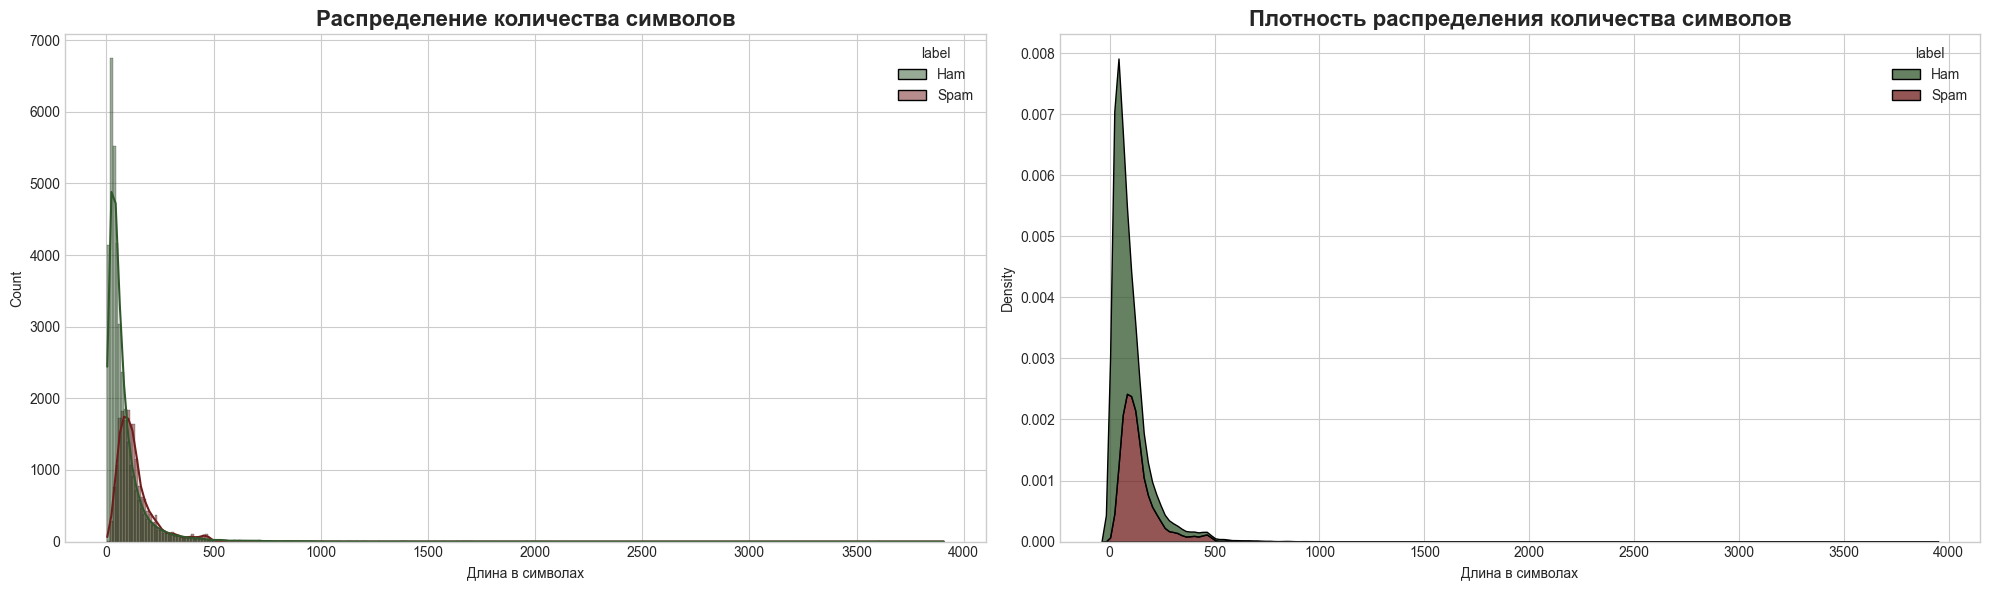

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.histplot(
    data=df, 
    x=df['text'].str.len(), 
    hue=df['label'].map({0: 'Ham', 1: 'Spam'}), 
    bins=300, 
    kde=True, 
    palette=["#31572c", '#6f1d1b'],
    ax=ax1
)
ax1.set_title('Распределение количества символов', fontweight='bold', fontsize=16)
ax1.set_xlabel('Длина в символах')

sns.kdeplot(
    data=df, 
    x=df['text'].str.len(), 
    hue=df['label'].map({0: 'Ham', 1: 'Spam'}), 
    multiple="stack",
    palette=["#31572c", '#6f1d1b'],
    ax=ax2
)
ax2.set_title('Плотность распределения количества символов', fontweight='bold', fontsize=16)
ax2.set_xlabel('Длина в символах')

plt.tight_layout()
plt.show()

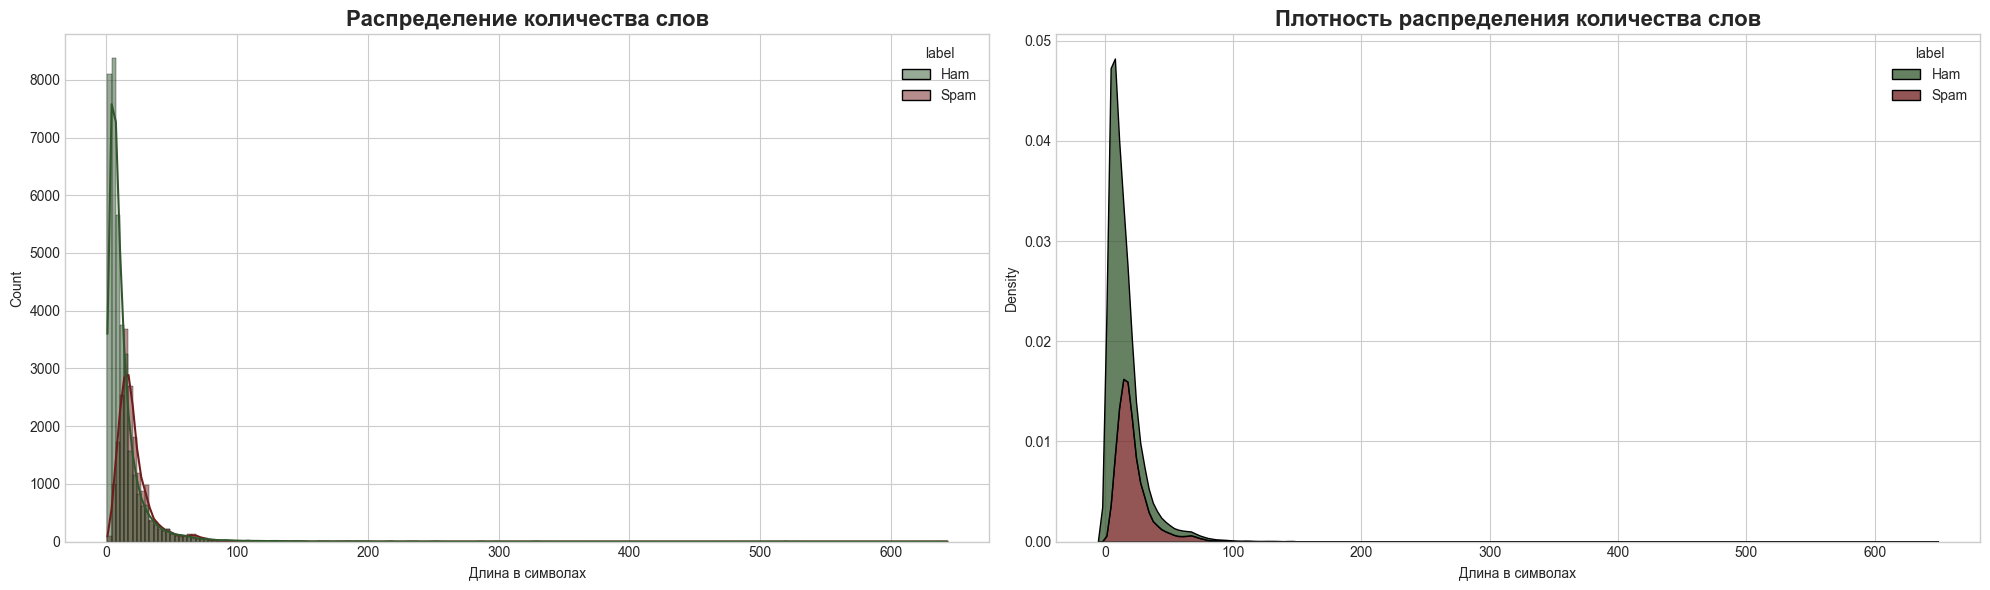

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.histplot(
    data=df, 
    x=df['text'].str.split().str.len(), 
    hue=df['label'].map({0: 'Ham', 1: 'Spam'}), 
    bins=200, 
    kde=True, 
    palette=["#31572c", '#6f1d1b'],
    ax=ax1
)
ax1.set_title('Распределение количества слов', fontweight='bold', fontsize=16)
ax1.set_xlabel('Длина в символах')

sns.kdeplot(
    data=df, 
    x=df['text'].str.split().str.len(), 
    hue=df['label'].map({0: 'Ham', 1: 'Spam'}), 
    multiple="stack",
    palette=["#31572c", '#6f1d1b'],
    ax=ax2
)
ax2.set_title('Плотность распределения количества слов', fontweight='bold', fontsize=16)
ax2.set_xlabel('Длина в символах')

plt.tight_layout()
plt.show()

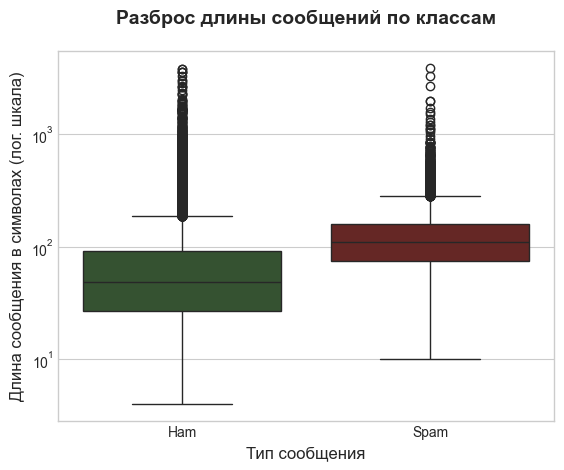

In [19]:
# Boxplot длины сообщений по классам (спам vs не спам)
sns.boxplot(
    data=df, 
    x='label', 
    y=df['text'].str.len(), 
    hue='label',
    palette=["#31572c", '#6f1d1b'],
    legend=False
)

plt.title('Разброс длины сообщений по классам', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Тип сообщения', fontsize=12)
plt.ylabel('Длина сообщения в символах (лог. шкала)', fontsize=12)
plt.yscale('log')
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.show()

In [22]:
# чистим

df = df.drop_duplicates(keep='first', ignore_index = True, subset = ['text_lemmatized'])
df.dropna(inplace = True, ignore_index = True)

print(f"Итоговый размер чистого датасета: {df.shape}")
print("\nНовое распределение классов:")
print(df['label'].value_counts(normalize=True) * 100)

Итоговый размер чистого датасета: (48400, 5)

Новое распределение классов:
label
0    72.332645
1    27.667355
Name: proportion, dtype: float64


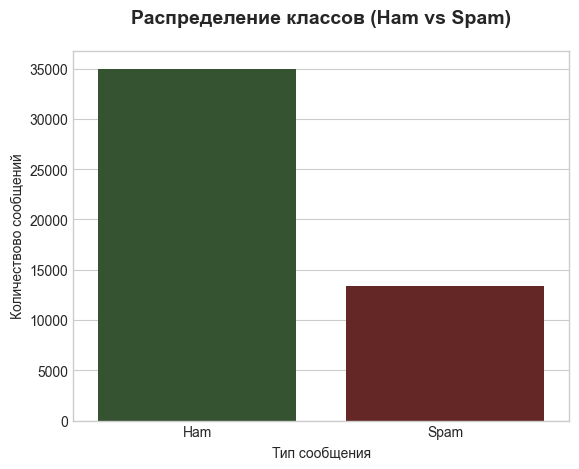

In [23]:
# график распределение сообщений 
sns.countplot(
    data=df,
    x='label', 
    hue='label',
    palette = ["#31572c", '#6f1d1b'],
    legend=False
)

plt.title('Распределение классов (Ham vs Spam)', fontsize=14, fontweight='bold', pad=20)

plt.xlabel('Тип сообщения')
plt.ylabel('Количествово сообщений')
plt.xticks([0, 1], ['Ham', 'Spam'])

plt.show()

### Облако слов для спам-сообщений

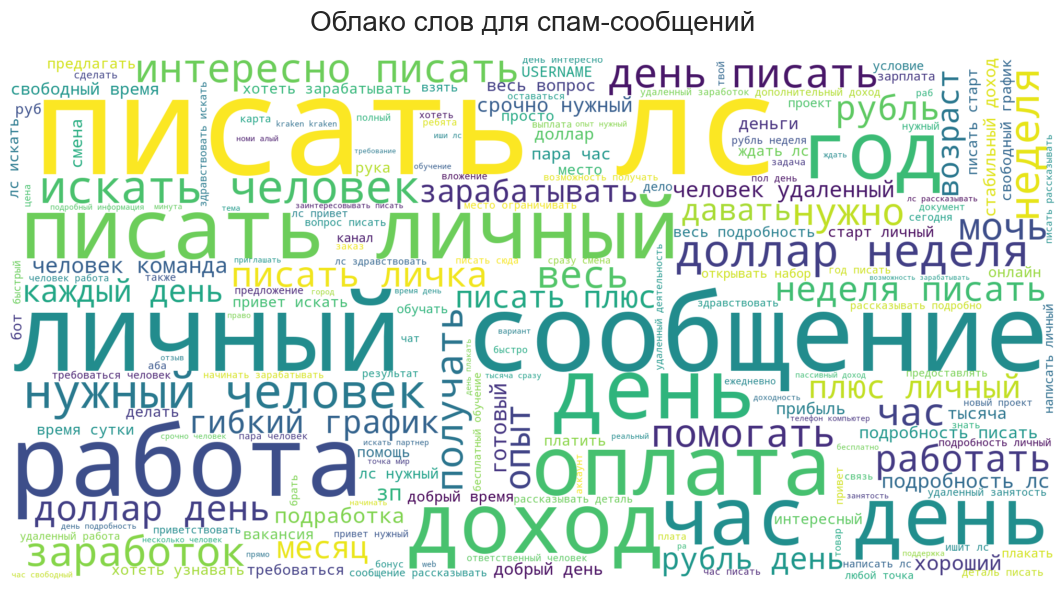

In [19]:
text = ' '.join(df[df.label == 1]['text_lemmatized'])

wordcloud = WordCloud(
    width=2000,
    height=1000,
    background_color='white',
    max_words = 200,
    colormap='viridis',
    stopwords=['NUM'],
    repeat=False,
    # mask=mask
).generate(text)

plt.figure(figsize = (12, 6))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.title('Облако слов для спам-сообщений', fontsize = 20, pad = 20)
plt.tight_layout()
plt.show()

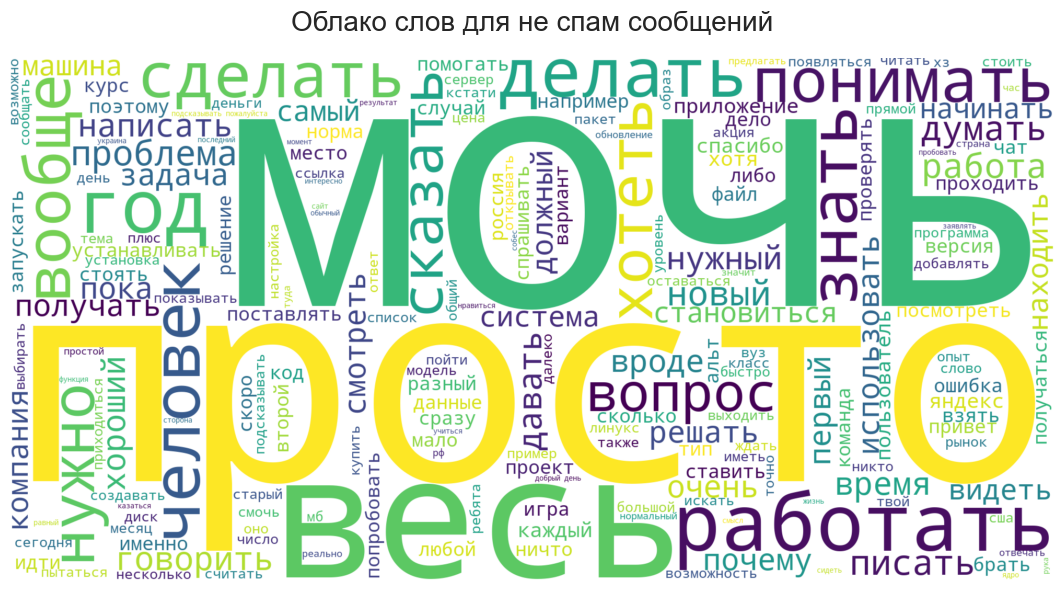

In [20]:
text = ' '.join(df[df.label == 0]['text_lemmatized'])
wordcloud = WordCloud(
    width=2000,
    height=1000,
    background_color='white',
    max_words = 200,
    colormap='viridis',
    stopwords=['NUM'],
    repeat=False,
).generate(text)

plt.figure(figsize = (12, 6))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.title('Облако слов для не спам сообщений', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

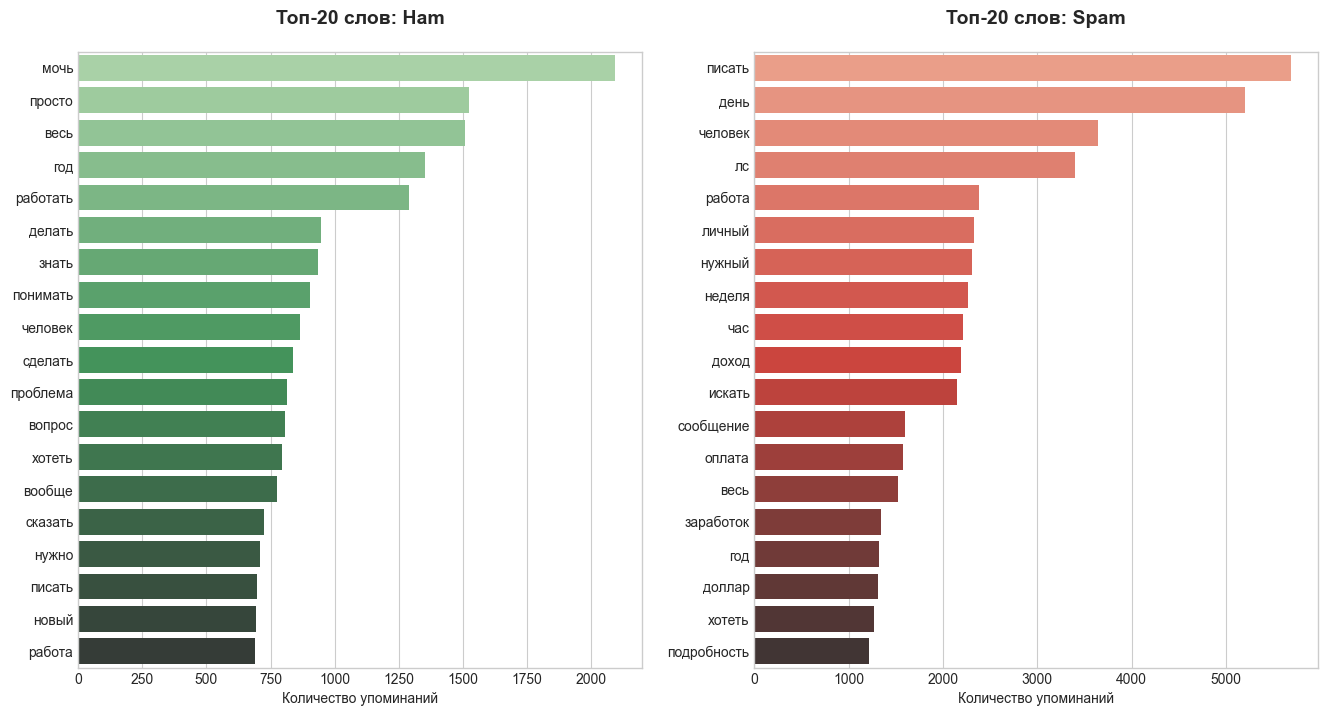

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
и
classes = [(0, 'Ham', 'Greens_d', axes[0]), (1, 'Spam', 'Reds_d', axes[1])]

for label_id, label_name, palette, ax in classes:
    top_words = df[df['label'] == label_id]['text_lemmatized'].str.split(expand=True).stack().value_counts().head(20)
    top_words = top_words.drop('NUM', errors='ignore')
    sns.barplot(x=top_words.values, y=top_words.index, ax=ax, palette=palette, hue=top_words.index, legend=False)
    ax.set_title(f'Топ-20 слов: {label_name}', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Количество упоминаний')
    ax.set_ylabel('')

plt.show()

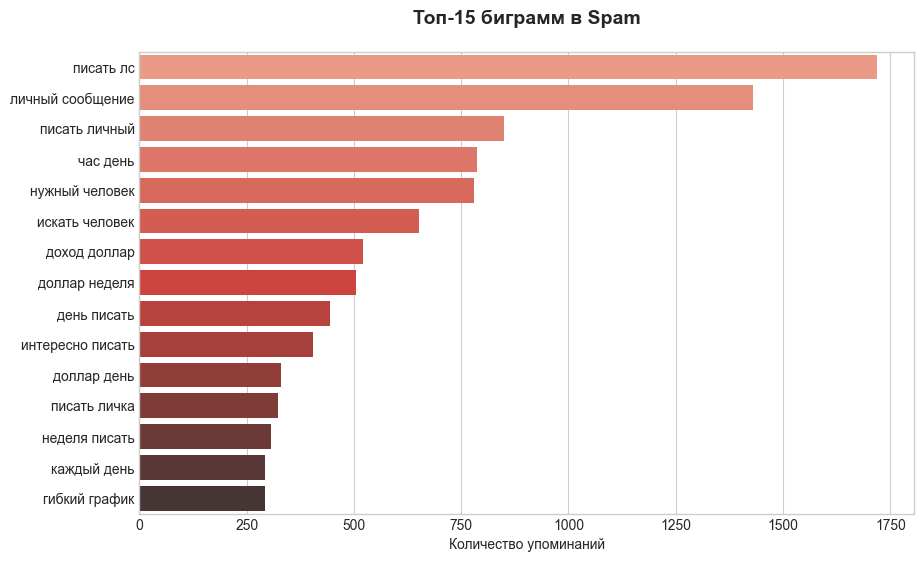

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=['num']).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:15]

top_n_bigrams = get_top_ngram(df[df.label == 1]['text_lemmatized'], 2)
x, y = map(list, zip(*top_n_bigrams))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=y, 
    y=x, 
    palette='Reds_d', 
    hue=x, 
    legend=False
    )

plt.title('Топ-15 биграмм в Spam', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Количество упоминаний')

plt.show()